11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Training Starting ---
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 52ms/step - accuracy: 0.9502 - loss: 0.1657 - val_accuracy: 0.9808 - val_loss: 0.0589
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.9849 - loss: 0.0495 - val_accuracy: 0.9847 - val_loss: 0.0436
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9897 - val_loss: 0.0316
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.9916 - loss: 0.0261 - val_accuracy: 0.9896 - val_loss: 0.0301
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.9935 - loss: 0.0206 - val_accuracy: 0.9899 - val_loss: 0.0277

--- Evaluation on Test Data ---
313/313 - 2s - 8ms/step - accuracy: 0.9899 - loss: 0.0277

Final Test Accuracy: 98.99%


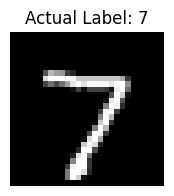

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Model Predicted: 7


In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Preprocess the MNIST Dataset
# MNIST dataset already Keras mein built-in hota hai, alag se download nahi karna padega.
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1 (for faster convergence)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape data to add channel dimension (28x28 grayscale images -> 28x28x1)
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


# 2. Build the CNN Model Architecture
model = models.Sequential([
    # First Convolutional Layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 2D features to 1D vector
    layers.Flatten(),

    # Fully Connected (Dense) Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes (digits 0-9)
])

# Print Model Summary (College file/PPT ke liye useful hai)
model.summary()


# 3. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# 4. Train the Model
print("\n--- Training Starting ---")
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=64)


# 5. Evaluate the Model Performance on Test Data
print("\n--- Evaluation on Test Data ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")


# 6. Make a Prediction (Sample Visual Verification)
plt.figure(figsize=(2,2))
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Actual Label: {y_test[0]}")
plt.axis('off')
plt.show()

prediction = model.predict(X_test[0].reshape(1, 28, 28, 1))
print(f"Model Predicted: {np.argmax(prediction)}")